In [1]:
!pip install -q --upgrade transformers datasets kaggle scikit-learn seaborn accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.7 MB/s eta 0:00:00


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dnandi","key":"24e60868ea7a8fc8dc48dba5439a3692"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d julian3833/jigsaw-toxic-comment-classification-challenge
!unzip -o jigsaw-toxic-comment-classification-challenge.zip

Dataset URL: https://www.kaggle.com/datasets/julian3833/jigsaw-toxic-comment-classification-challenge
License(s): CC0-1.0
100% 53.4M/53.4M [00:05<00:00, 10.5MB/s]

Archive:  jigsaw-toxic-comment-classification-challenge.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: test_labels.csv         
  inflating: train.csv               


In [5]:
import pandas as pd
import re
df = pd.read_csv("train.csv")
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [6]:
labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
df.dropna(subset=['comment_text'], inplace=True)

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"<.*?>", "", text)
    return text
df['comment_text'] = df['comment_text'].apply(clean_text)
df = df[['comment_text'] + labels]
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,explanation why the edits made under my userna...,0,0,0,0,0,0
1,d'aww! he matches this background colour i'm s...,0,0,0,0,0,0
2,"hey man, i'm really not trying to edit war. it...",0,0,0,0,0,0
3,""" more i can't make any real suggestions on im...",0,0,0,0,0,0
4,"you, sir, are my hero. any chance you remember...",0,0,0,0,0,0


In [8]:
from sklearn.model_selection import train_test_split
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['comment_text'], df[labels], test_size=0.2, random_state=42
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

In [9]:
import torch
label_counts = df[labels].sum()
total_samples = len(df)
pos_weights = (total_samples - label_counts) / (label_counts + 1e-5)
pos_weights_tensor = torch.tensor(pos_weights.values, dtype=torch.float)
print("Class weights:\n", pos_weights)

Class weights:
 toxic              9.433569
severe_toxic      99.044513
obscene           17.886377
threat           332.830537
insult            19.257839
identity_hate    112.573665
dtype: float64


In [10]:
from transformers import AutoTokenizer
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [11]:
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings   = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_encodings  = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)

In [12]:
import torch
class ToxicDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item
    def __len__(self):
        return len(self.labels)

In [13]:
train_dataset = ToxicDataset(train_encodings, train_labels)
val_dataset   = ToxicDataset(val_encodings, val_labels)
test_dataset  = ToxicDataset(test_encodings, test_labels)

In [14]:
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    problem_type="multi_label_classification"
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs > 0.5).astype(int)
    return {
        "f1_micro": f1_score(labels, preds, average="micro"),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision": precision_score(labels, preds, average="micro"),
        "recall": recall_score(labels, preds, average="micro")
    }

In [16]:
from transformers import TrainingArguments
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=200,
    load_best_model_at_end=True,
    fp16=True,
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [17]:
from transformers import Trainer, EarlyStoppingCallback
import torch.nn as nn
class WeightedTrainer(Trainer):
    def __init__(self, pos_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weights = pos_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.BCEWithLogitsLoss(
            pos_weight=self.pos_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    pos_weights=pos_weights_tensor
)

In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Precision,Recall
1,0.531171,0.519365,0.745622,0.649085,0.631168,0.910780
2,0.406160,0.704154,0.764050,0.652153,0.676203,0.878131
3,0.187715,0.916669,0.774965,0.665682,0.707057,0.857304


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=23937, training_loss=0.32445476528954503, metrics={'train_runtime': 1752.8276, 'train_samples_per_second': 218.486, 'train_steps_per_second': 13.656, 'total_flos': 1.2683598393470976e+16, 'train_loss': 0.32445476528954503, 'epoch': 3.0})

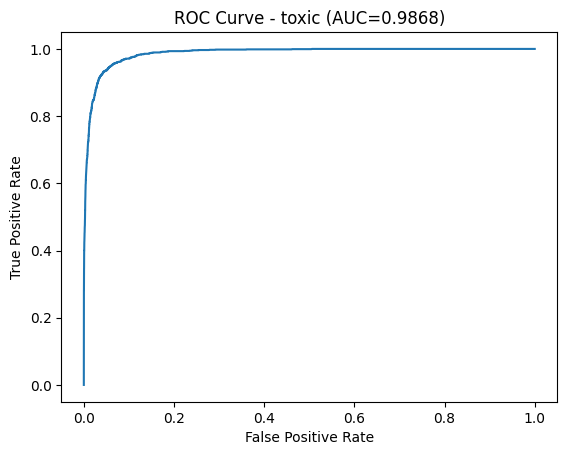

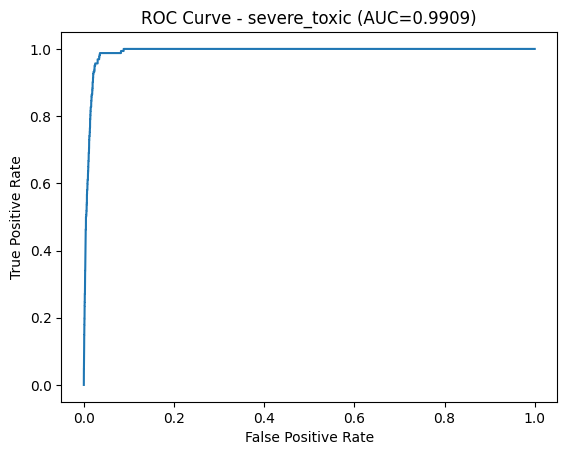

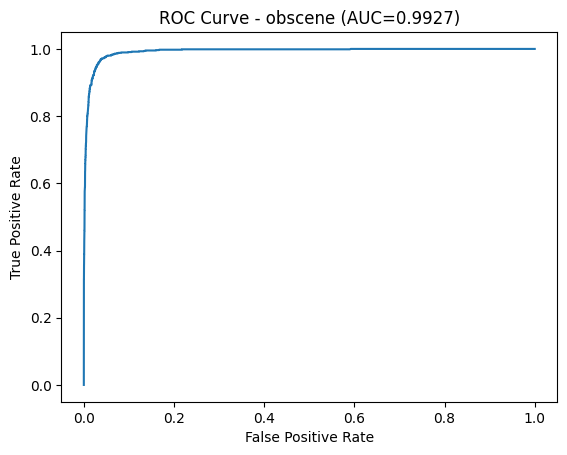

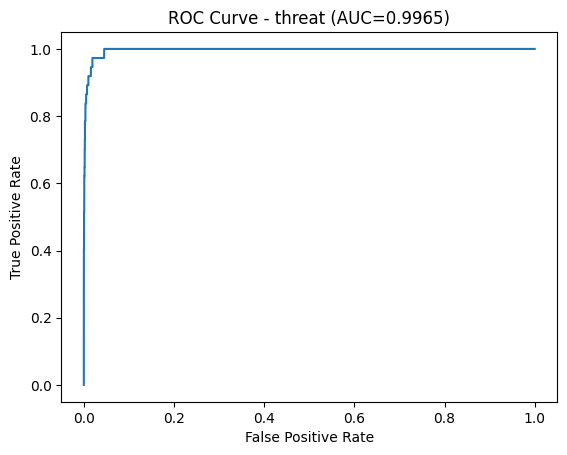

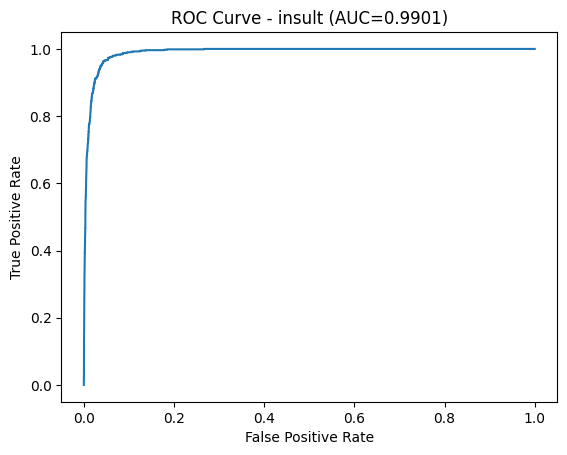

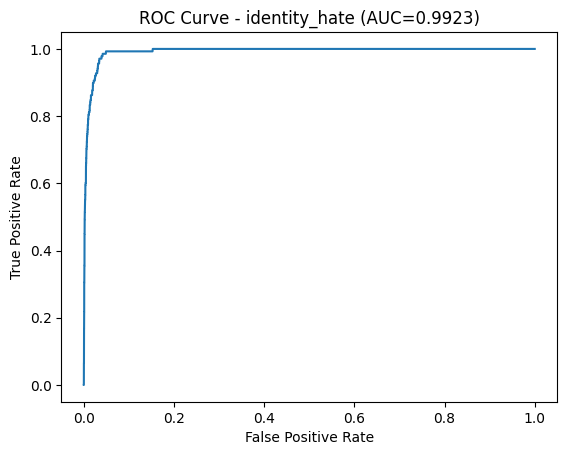

ROC-AUC per class:
toxic: 0.9868
severe_toxic: 0.9909
obscene: 0.9927
threat: 0.9965
insult: 0.9901
identity_hate: 0.9923


In [22]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
preds = trainer.predict(test_dataset)
logits = preds.predictions
probs = 1 / (1 + np.exp(-logits))
roc_auc_dict = {}
for i, label in enumerate(labels):
    auc = roc_auc_score(test_labels.iloc[:, i], probs[:, i])
    roc_auc_dict[label] = auc
    fpr, tpr, _ = roc_curve(test_labels.iloc[:, i], probs[:, i])
    plt.figure()
    plt.plot(fpr, tpr)
    plt.title(f"ROC Curve - {label} (AUC={auc:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()
print("ROC-AUC per class:")
for k, v in roc_auc_dict.items():
    print(f"{k}: {v:.4f}")

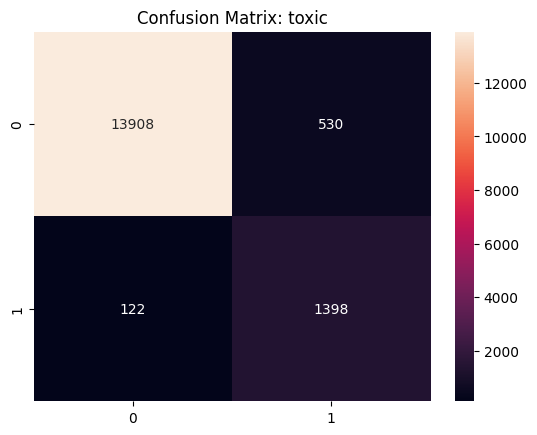

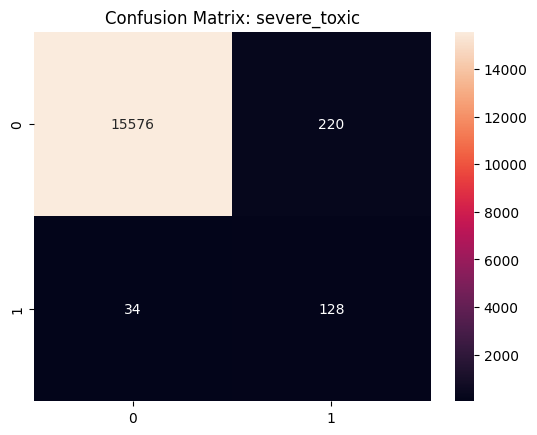

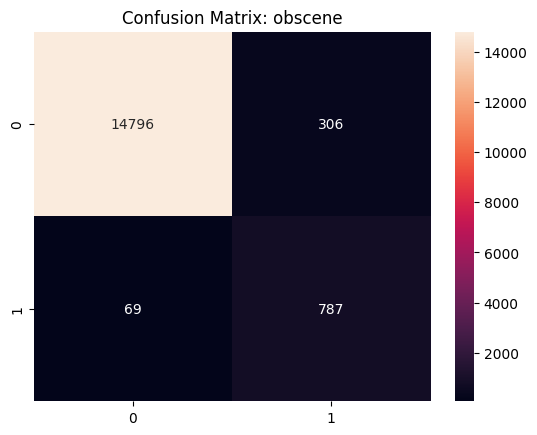

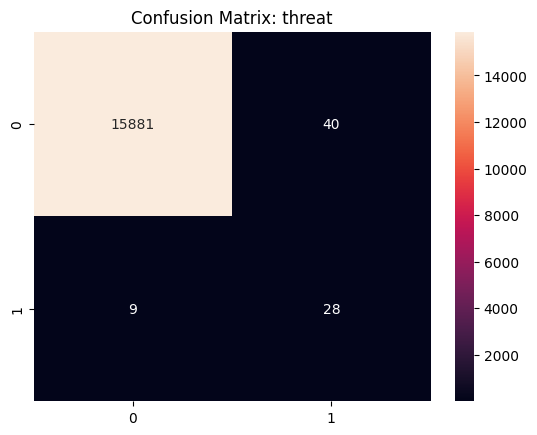

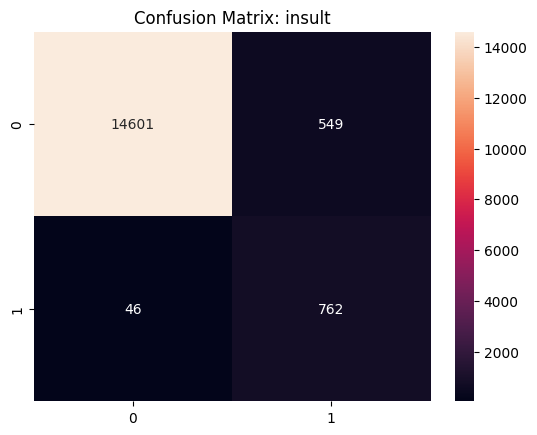

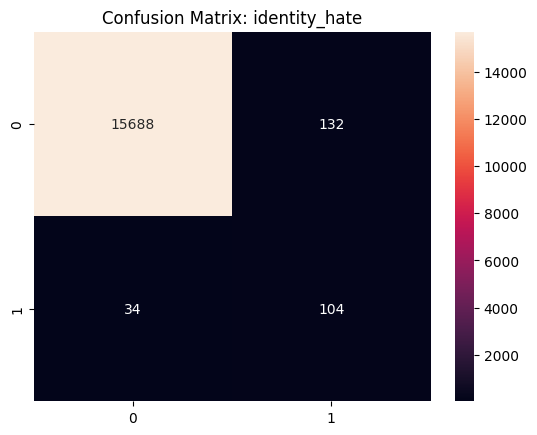

In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = (probs > 0.5).astype(int)

for i, label in enumerate(labels):
    cm = confusion_matrix(test_labels.iloc[:, i], y_pred[:, i])

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix: {label}")
    plt.show()

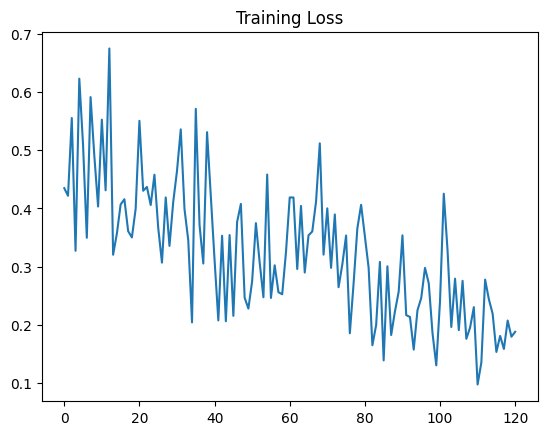

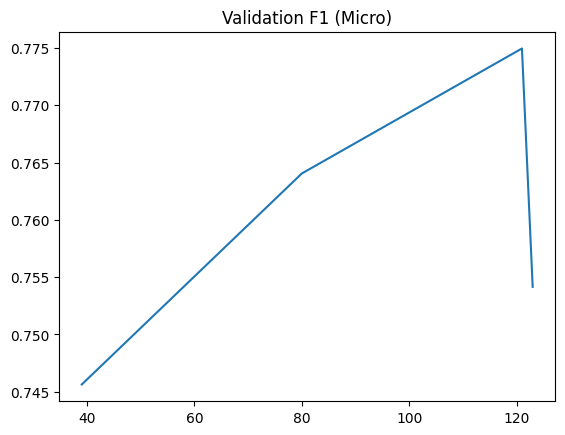

In [24]:
import pandas as pd

history = pd.DataFrame(trainer.state.log_history)

# Loss
plt.figure()
plt.plot(history["loss"].dropna())
plt.title("Training Loss")
plt.show()

# F1
eval_f1 = history[history["eval_f1_micro"].notna()]

plt.figure()
plt.plot(eval_f1["eval_f1_micro"])
plt.title("Validation F1 (Micro)")
plt.show()

In [25]:
from sklearn.metrics import classification_report

y_pred = (probs > 0.5).astype(int)

print(classification_report(test_labels, y_pred, target_names=labels))

               precision    recall  f1-score   support

        toxic       0.73      0.92      0.81      1520
 severe_toxic       0.37      0.79      0.50       162
      obscene       0.72      0.92      0.81       856
       threat       0.41      0.76      0.53        37
       insult       0.58      0.94      0.72       808
identity_hate       0.44      0.75      0.56       138

    micro avg       0.64      0.91      0.75      3521
    macro avg       0.54      0.85      0.65      3521
 weighted avg       0.66      0.91      0.76      3521
  samples avg       0.07      0.09      0.07      3521



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
